In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import joblib

In [23]:
np.random.seed(0)
try:
    df = pd.read_csv('https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/mall_customers.csv')
    df = df.rename(columns={'Annual Income (k$)': 'Income', 'Spending Score (1-100)': 'Score'})
    X = df[['Income', 'Score']]
except:
    print("Données de secours")
    from sklearn.datasets import make_blobs
    X, _ = make_blobs(n_samples=200, centers=5, cluster_std=1.2, random_state=42)
    X = pd.DataFrame(X, columns=['Income', 'Score'])

Données de secours


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Génération du Dendrogramme avec la méthode de Ward


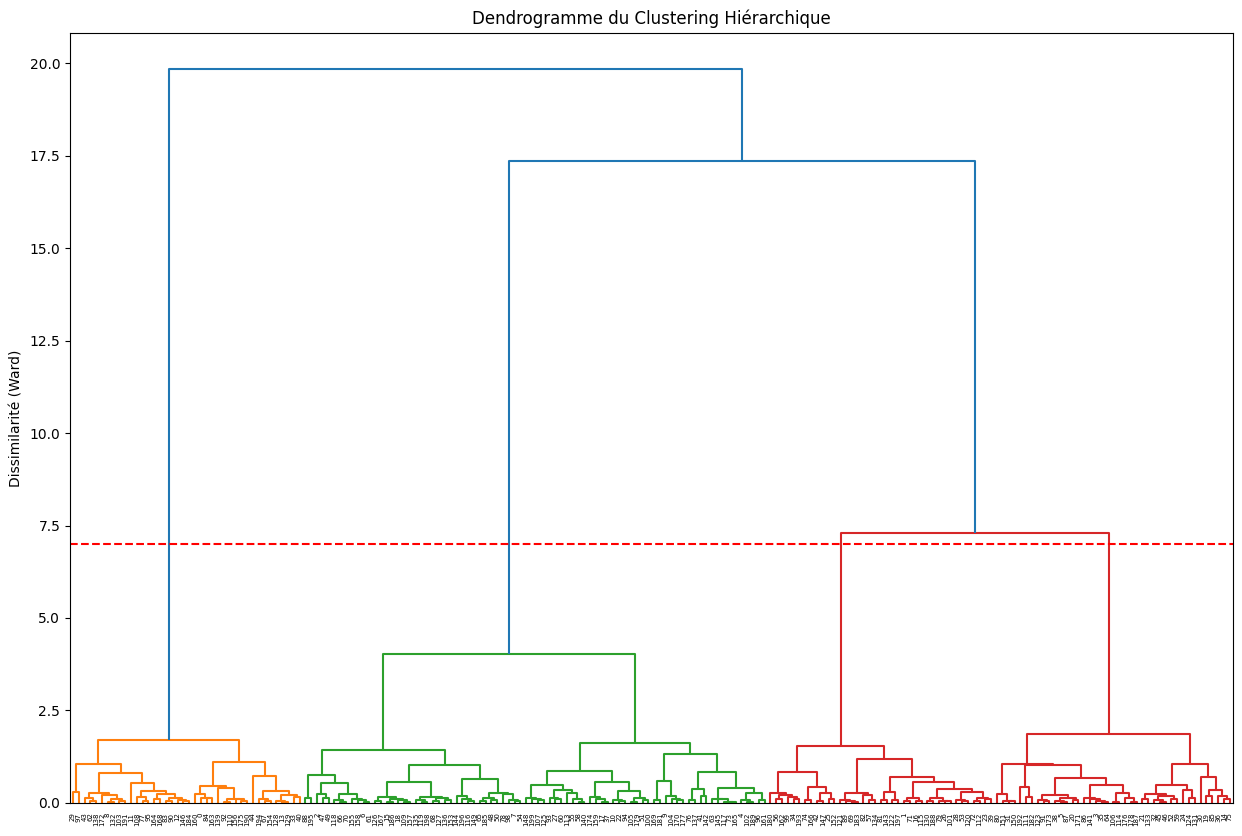

In [33]:
print("Génération du Dendrogramme avec la méthode de Ward")
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(15, 10))
dendrogram(linked)
plt.title("Dendrogramme du Clustering Hiérarchique")
plt.ylabel("Dissimilarité (Ward)")
plt.axhline(7, c="r", ls="--")
plt.show()

In [34]:
k = 4
agg_cluster = AgglomerativeClustering(n_clusters=k, linkage='ward')
labels = agg_cluster.fit_predict(X_scaled)

In [41]:
sil_score = silhouette_score(X_scaled, labels)
print(f"Silhouette score : {sil_score:.4f}")

Silhouette score : 0.6871


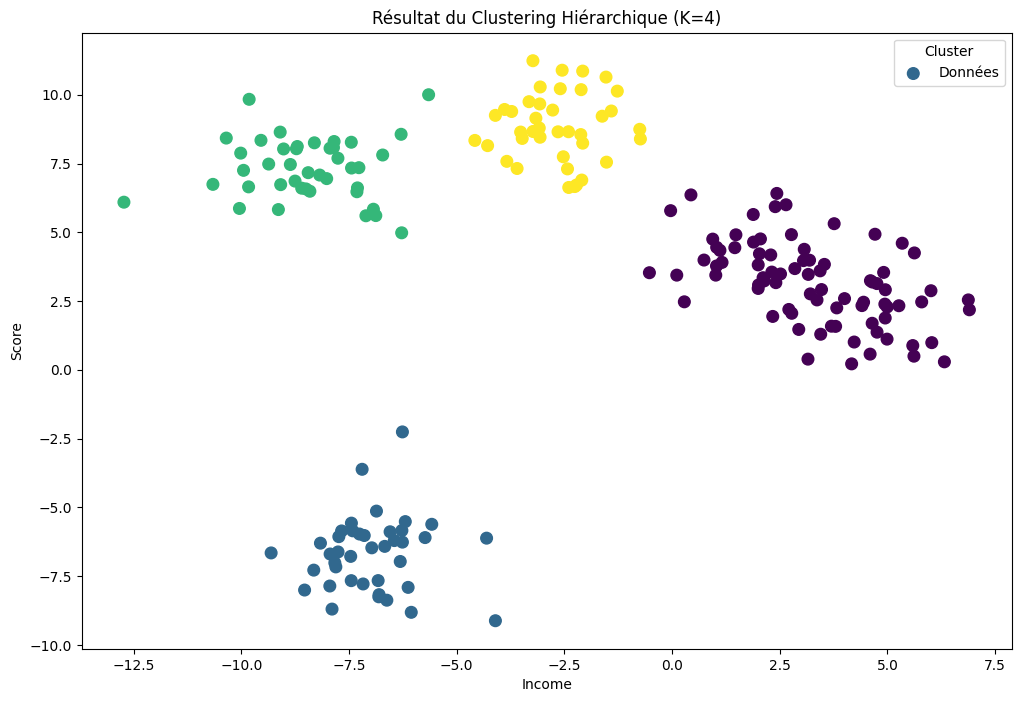

In [38]:
plt.figure(figsize=(12, 8))
plt.scatter(X["Income"], X["Score"], c=labels, cmap="viridis",s=70 ,label="Données")
plt.title(f"Résultat du Clustering Hiérarchique (K={k})")
plt.xlabel("Income")
plt.ylabel("Score")
plt.legend(title="Cluster")
plt.show()

In [36]:
joblib.dump(agg_cluster, 'agglomerative_clustering_model.pkl')
joblib.dump(scaler, 'scaler_agg.pkl')
print("Modèle de clustering agglomérative sauvegardé")

Modèle de clustering agglomérative sauvegardé
